# Description | Inspecting trait-like behaviors in SNYCQ data

This notebook runs additional analyses regarding whether or not thought patterns are systematically similar across scans, using three methods:

* Rate of repeated scans being part of the same set
* Differntial Identifiability: as described in [The quest for identifiability in human functional connectomes](https://www.nature.com/articles/s41598-018-25089-1) by Amico & Goñi (Scientific Reports, 2018)
* Identifiability Rate: as described in [Functional connectome fingerprinting: identifying individuals using patterns of brain activity](https://www.nature.com/articles/nn.4135) by Finn et al. (Nat. Neuro, 2015)



In [45]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from textwrap import wrap
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.colors as colors
from utils.io import read_fc_matrices
from utils.basics import DATA_DIR, FB_400ROI_ATLAS_NAME, RESOURCES_SNYCQ_DIR
import os.path as osp
from random import shuffle
import warnings
import hvplot.pandas
from matplotlib import colors as mcolors
warnings.simplefilter(action='ignore', category=FutureWarning)

***
# 1. Percent of scans in the same clsuter several times

The first way we look at the question of whether introspective reports are trait-like is by looking by how often all scans from the same subject fall in the same scan set (as defined in the previous notebook)

1. Load SNYCQ items and clustering info

In [2]:
emb_plus  = pd.read_csv(osp.join(RESOURCES_SNYCQ_DIR, 'SNYCQ_tsne_embeddings_plus_scaled.csv'), index_col=[0,1])
scan_list = emb_plus.index.tolist() 
sbj_list  = list(emb_plus.index.get_level_values('Subject').unique())
print('++ [post_introspection_outlier] Number of subjects: %d subjects' % len(scan_list))
print('++ [post_introspection_outlier] Number of scans:    %d scans' % len(sbj_list))
emb_plus.head(2)


++ [post_introspection_outlier] Number of subjects: 469 subjects
++ [post_introspection_outlier] Number of scans:    133 scans


TSNE1     TSNE2     TSNE3  Positive  \
Subject    Run                                                                 
sub-010014 post-ses-02-run-01-acq-AP  2.843978 -5.001404 -1.030443       0.6   
           post-ses-02-run-01-acq-PA  0.480376  2.531097 -1.479478      -0.2   

                                      Negative  Future   Past    Myself  \
Subject    Run                                                            
sub-010014 post-ses-02-run-01-acq-AP -0.428571    -0.6  0.125 -0.714286   
           post-ses-02-run-01-acq-PA -0.571429     0.4  0.500  0.285714   

                                      People  Surroundings    Images  \
Subject    Run                                                         
sub-010014 post-ses-02-run-01-acq-AP    -0.2      0.117647  0.714286   
           post-ses-02-run-01-acq-PA    -0.2      0.705882  0.714286   

                                         Words  Specific  Intrusive Set Label  \
Subject    Run                                                                  
sub-010014 post-ses-02-run-01-acq-AP  0.842105    -0.875  -0.285714     Set B   
           post-ses-02-run-01-acq-PA  0.736842    -0.875   0.428571     Set B   

                                      Group Probability  
Subject    Run                                           
sub-010014 post-ses-02-run-01-acq-AP           0.925632  
           post-ses-02-run-01-acq-PA           0.939779

2. Count how many scans we have per subject. Only scans from subjects that were scanned at least three time will be used in these analyses

In [3]:
N_MIN_SCANS = 3

# Count the number of runs per subject
scan_list_df = pd.DataFrame(scan_list,columns=['Subject','Run'])
run_counts   = scan_list_df.groupby("Subject")["Run"].nunique().to_frame(name="NumRuns")

sbjs_sel_scans = run_counts[run_counts["NumRuns"] >= N_MIN_SCANS].index.tolist()

3. Print information regarding how many scans, subjects, etc enter these analyses

In [4]:
Nsbjs_total       = len(emb_plus.index.get_level_values('Subject').unique())
Nsbjs_sel_scans   = len(sbjs_sel_scans)
Nselected_scans   = emb_plus.loc[sbjs_sel_scans].shape[0]
print('++ INFO: Number of subjects in these analyses    : %d subjects' % Nsbjs_total)
print('++ INFO: Number of subjects with %d or more scans : %d subjects' % (N_MIN_SCANS,Nsbjs_sel_scans))
print('++ INFO: Number of scans (for subjects with %d or more scans : %d subjects' % (N_MIN_SCANS,Nselected_scans))

++ INFO: Number of subjects in these analyses    : 133 subjects
++ INFO: Number of subjects with 3 or more scans : 116 subjects
++ INFO: Number of scans (for subjects with 3 or more scans : 442 subjects


4. Count the prevalence of scans in the same set

In [5]:
def count_scans_per_group(sbjs,cluster_info):
    # Extract from cluster_info structure the entries for scans with 2 or more scans
    df = pd.DataFrame(0, index=sbjs, columns=['All scans in same set','All except one scan in same set','Other configuration'], dtype=int)
    aux = cluster_info.loc[sbjs,'Set Label']
    n_scans = aux.shape[0]
    for sbj in aux.index.get_level_values('Subject'):
        auxx = aux.loc[sbj,:]
        auxx_max = auxx.value_counts().max()
        if auxx_max == 4:
            df.loc[sbj,'All scans in same set'] = 1
        elif auxx_max == (auxx.shape[0]-1):
            df.loc[sbj,'All except one scan in same set'] = 1
        else:
            df.loc[sbj,'Other configuration'] = 1
    return df.sum()

5. Plot the results


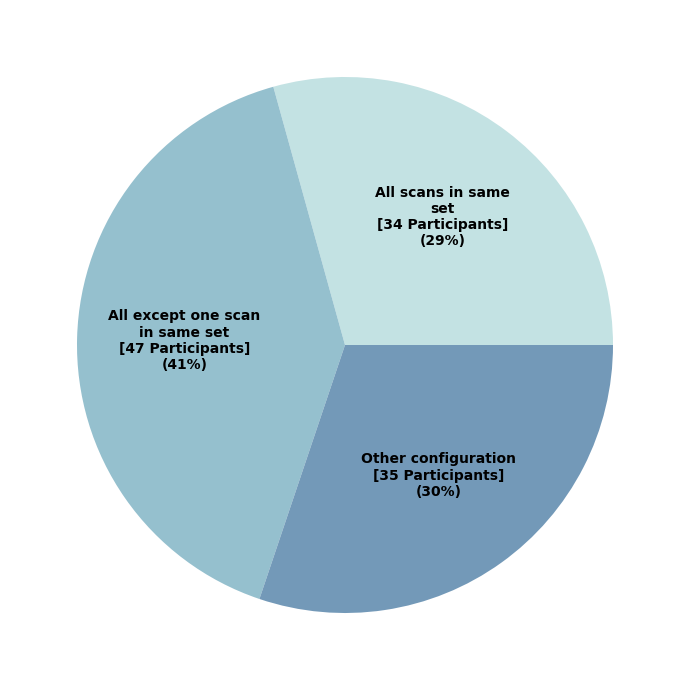

In [6]:
final_counts = count_scans_per_group(sbjs_sel_scans, emb_plus)
labels = final_counts.index

# Wrap labels to avoid overlap
labels = ['\n'.join(wrap(l, 20)) for l in labels]

# Define a custom label function
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        # Return both label and percentage
        return f"[{val} Participants]\n({pct:.0f}%)"
    return my_autopct

fig, ax = plt.subplots(figsize=(7,7))
colors = sns.color_palette("ch:start=.2,rot=-.3")
wedges, texts, autotexts = ax.pie(
    final_counts,
    labels=None,                      # don't use default labels outside
    colors=colors,
    autopct=make_autopct(final_counts),  # include text inside
    textprops={'color':"black", 'fontsize':10, 'weight':'bold'}
)

# Manually add labels to the center of each wedge
for i, a in enumerate(autotexts):
    a.set_text(f"{labels[i]}\n{a.get_text()}")  # add label + percentage

plt.tight_layout()
plt.show()


In [7]:
fig.savefig(osp.join('figures', 'Figure02_A-ScanMembershipConsistency.png'), bbox_inches='tight')

***
# 2. Differential Identifibiability

Here, we compute Idiff (Differential Identifiability) following the procedure described by [Amico et al. (2018)](https://www.nature.com/articles/s41598-018-25089-1)

1. Identify scans from subjects that were scanned at least twice.

In [8]:
# Identify the runs with less than 2 scans
subjects_lt2 = run_counts[run_counts["NumRuns"] < 2].index.tolist()
# Create mask with True for scans we want to keep and False for those to remove
mask = emb_plus.index.get_level_values("Subject").isin(subjects_lt2)

In [9]:
# These scans / subjects will not enter the identifiability analyses
scan_list_df[mask]

,Subject,Run
123,sub-010127,post-ses-02-run-02-acq-PA
124,sub-010128,post-ses-02-run-02-acq-AP
173,sub-010152,post-ses-02-run-01-acq-PA
281,sub-010198,post-ses-02-run-02-acq-AP
430,sub-010064,post-ses-02-run-01-acq-PA
431,sub-010065,post-ses-02-run-01-acq-AP
458,sub-010075,post-ses-02-run-01-acq-PA


2. Create an index with only the scans from subjects with at least two visits

In [10]:
# Remove from the introspection dataframe the entries for scans that are single entries per subject
scans_for_identifiability = emb_plus.copy().loc[~mask].index
#scans_by_cluster          = emb_plus.copy().loc[~mask].sort_values(by=['Set Label']).index
print('++ Number of scans used in identifiability analyses: %d scans' % len(scans_for_identifiability))

++ Number of scans used in identifiability analyses: 462 scans


3. Create a list of the subjects that enter the anlyses

In [11]:
# Number of subjects entering the analyses
sbjs_for_identifiability = scans_for_identifiability.get_level_values('Subject').unique().tolist()
print('++ Number of subjects used in identifiability analyses: %d subjects' % len(sbjs_for_identifiability))

++ Number of subjects used in identifiability analyses: 126 subjects


## 2.1. Differential Identifiability for Introspection data

1. Create a new dataframe that only contains the SNYCQ items of interest (all but vigilance) for the subjects and scans with 2+ visits.



In [12]:
# Remove the Vigilance entry to match all other analyses
SNYCQ_for_identifiability = emb_plus.loc[scans_for_identifiability].drop(['TSNE1','TSNE2','TSNE3','Group Probability','Set Label'],axis=1)
print(SNYCQ_for_identifiability.shape)

(462, 11)


2. Estimate the Identifiability Matrix (correlation of each scan to every other scan) --> This is at the scan level.

In [13]:
def get_scan_level_identifiability_matrix(dataframe):
    Id_matrix = dataframe.T.corr(method='pearson').values
    np.fill_diagonal(Id_matrix,np.nan)
    Id_matrix = pd.DataFrame(Id_matrix,index=dataframe.index,columns=dataframe.index)
    return Id_matrix

In [15]:
Id_SNYCQ_scans = get_scan_level_identifiability_matrix(SNYCQ_for_identifiability)
Id_SNYCQ_scans.head(3).round(2)

Subject                                             sub-010014  \
Run                                  post-ses-02-run-01-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                       NaN   
           post-ses-02-run-01-acq-PA                      0.54   
           post-ses-02-run-02-acq-AP                      0.28   

Subject                                                         \
Run                                  post-ses-02-run-01-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.54   
           post-ses-02-run-01-acq-PA                       NaN   
           post-ses-02-run-02-acq-AP                      0.41   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.28   
           post-ses-02-run-01-acq-PA                      0.41   
           post-ses-02-run-02-acq-AP                       NaN   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                     -0.04   
           post-ses-02-run-01-acq-PA                      0.36   
           post-ses-02-run-02-acq-AP                      0.75   

Subject                                             sub-010080  \
Run                                  post-ses-02-run-02-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.63   
           post-ses-02-run-01-acq-PA                      0.13   
           post-ses-02-run-02-acq-AP                      0.02   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.12   
           post-ses-02-run-01-acq-PA                     -0.21   
           post-ses-02-run-02-acq-AP                     -0.74   

Subject                                             sub-010082  \
Run                                  post-ses-02-run-01-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                     -0.30   
           post-ses-02-run-01-acq-PA                     -0.09   
           post-ses-02-run-02-acq-AP                      0.39   

Subject                                                         \
Run                                  post-ses-02-run-01-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                     -0.36   
           post-ses-02-run-01-acq-PA                     -0.18   
           post-ses-02-run-02-acq-AP                      0.51   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                     -0.27   
           post-ses-02-run-01-acq-PA                     -0.18   
           post-ses-02-run-02-acq-AP                      0.51   

Subject                                             sub-010084  ...  \
Run                                  post-ses-02-run-01-acq-AP  ...   
Subject    Run                                                  ...   
sub-010014 post-ses-02-run-01-acq-AP                      0.07  ...   
           post-ses-02-run-01-acq-PA                     -0.10  ...   
           post-ses-02-run-02-acq-AP                     -0.09  ...   



3. Use the scan-level Identifiability matrix to compute the subject-level identifiability matrix

In [16]:
def get_subject_level_identifiability_matrix(scan_level_Id_matrix):
    """
    Computes the subject-level identifiability matrix from the scan-level identifiability matrix.
    Parameters:
    scan_level_Id_matrix (pd.DataFrame): DataFrame where both rows and columns are scan IDs, and values are identifiability scores.
    Returns:
    pd.DataFrame: Subject-level identifiability matrix.
    """
    subjects_list = scan_level_Id_matrix.index.get_level_values('Subject').unique().tolist()  
    Id_subjects = pd.DataFrame(np.nan,index=subjects_list,columns=subjects_list, dtype=np.float32)
    for sbj_i in tqdm(subjects_list):
        for sbj_j in subjects_list:
            aux = scan_level_Id_matrix.loc[sbj_i][sbj_j].values
            if sbj_i == sbj_j:
                new_value = aux[np.triu_indices_from(aux, k=1)].mean()
                if pd.isna(Id_subjects.loc[sbj_i, sbj_j]):
                    Id_subjects.loc[sbj_i, sbj_j] = new_value
                else:
                    assert Id_subjects.loc[sbj_i, sbj_j] == new_value, "Inconsistent value found!"
            else:
                Id_subjects.loc[sbj_i, sbj_j] = aux.mean().mean() 
    return Id_subjects

In [17]:
Id_SNYCQ_sbjs = get_subject_level_identifiability_matrix(Id_SNYCQ_scans)

100%|██████████| 126/126 [00:11<00:00, 10.56it/s]


4. Compute ISelf, IOther and IDiff

In [18]:
Iself  = np.diag(Id_SNYCQ_sbjs.values).mean()
Iother = np.concatenate([Id_SNYCQ_sbjs.values[np.triu_indices_from(Id_SNYCQ_sbjs.values, k=1)],Id_SNYCQ_sbjs.values[np.tril_indices_from(Id_SNYCQ_sbjs.values, k=1)]]).mean()
Idiff   = 100 * (Iself - Iother)
print('++ Introspection ISelf = %.2f' %Iself)
print('++ Introspection IOther = %.2f' %Iother)
print ('++ Identifiability based on Introspection data = %.1f %%' % Idiff)


++ Introspection ISelf = 0.43
++ Introspection IOther = 0.01
++ Identifiability based on Introspection data = 41.7 %


5. Plot the Identifiability Matrix at the subject level

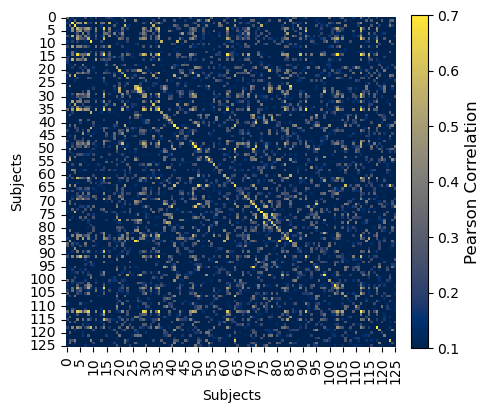

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
hm = sns.heatmap(
    Id_SNYCQ_sbjs.values,
    vmin=0.1,
    vmax=0.7,
    cmap='cividis',
    square=True,
    ax=ax,
    cbar=False   # turn off automatic colorbar
)

# Add colorbar manually
cbar = ax.figure.colorbar(hm.get_children()[0], ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Pearson Correlation', fontsize=12)

# Labels and ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
ax.set_xlabel('Subjects')
ax.set_ylabel('Subjects')

plt.tight_layout()
plt.show()

In [21]:
fig.savefig(osp.join('figures', 'Figure02_B-SNYCQ_IdentifiabilityMatrix.png'), bbox_inches='tight')

6. Create histograms of values contributing to Iself and Iother

In [22]:
# Create mask matrix that only contains 1 for scans that are from the same subject
row_subj = Id_SNYCQ_scans.index.get_level_values("Subject").to_numpy()
col_subj = Id_SNYCQ_scans.columns.get_level_values("Subject").to_numpy()

within_sbj_mask = pd.DataFrame(
                    (row_subj[:, None] == col_subj[None, :]).astype(bool),
                     index=Id_SNYCQ_scans.index,
                     columns=Id_SNYCQ_scans.columns)
across_sbj_mask = ~within_sbj_mask
within_sbj_mask.values[range(len(within_sbj_mask)),range(len(within_sbj_mask))] = False 

In [23]:
Iself_values_SNYCQ = Id_SNYCQ_scans[within_sbj_mask].values.flatten()
Iself_values_SNYCQ = Iself_values_SNYCQ[~np.isnan(Iself_values_SNYCQ)]
Iself_SNYCQ        = Iself_values_SNYCQ.mean()
print('++ Introspection Iself = %.5f ' % Iself_SNYCQ)

++ Introspection Iself = 0.43033 


In [24]:
Iother_values_SNYCQ = Id_SNYCQ_scans[across_sbj_mask].values.flatten()
Iother_values_SNYCQ = Iother_values_SNYCQ[~np.isnan(Iother_values_SNYCQ)]
Iother_SNYCQ        = Iother_values_SNYCQ.mean() 
print('++ Introspection Iother = %.5f ' % Iother_SNYCQ)

++ Introspection Iother = 0.00803 


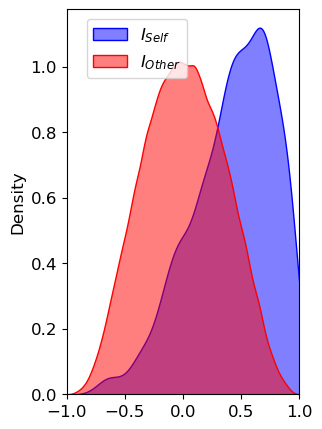

In [28]:
fig, ax = plt.subplots(figsize=(3,5))

sns.kdeplot(Iself_values_SNYCQ, label=r'$I_{Self}$', alpha=0.5, color='blue', fill=True, ax=ax)
sns.kdeplot(Iother_values_SNYCQ, label=r'$I_{Other}$', alpha=0.5, color='red', fill=True, ax=ax)

# Move legend inside the plot, bottom-left
ax.legend(
    loc='lower left',
    bbox_to_anchor=(0.05, 0.80),
    frameon=True,
    framealpha=0.8,
    fontsize=12,
)

# Set tick label size
ax.tick_params(axis='both', labelsize=12)

# Set axis labels (if you have them)
ax.set_ylabel('Density', fontsize=12)

# Set axis limits
ax.set_xlim(-1., 1)

#plt.tight_layout()
plt.show()


In [30]:
fig.savefig(osp.join('figures', 'Figure02_C-SNYCQ_IselfAndIother.png'), bbox_inches='tight')

## 2.2. Differential Identifiability based on FC

1. Load Pre-processed FC matrices for scans in these analyses

In [31]:
FC_for_identifiability = read_fc_matrices(scans_for_identifiability,DATA_DIR,FB_400ROI_ATLAS_NAME,'pb06_staticFC')

Scan: 100%|██████████| 462/462 [00:11<00:00, 40.03it/s]


2. Compute the scan-level identifiability matrix

In [ ]:
Id_FC_scans = get_scan_level_identifiability_matrix(FC_for_identifiability)
Id_FC_scans.head(3).round(2)

Subject                                             sub-010014  \
Run                                  post-ses-02-run-01-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                       NaN   
           post-ses-02-run-01-acq-PA                      0.80   
           post-ses-02-run-02-acq-AP                      0.78   

Subject                                                         \
Run                                  post-ses-02-run-01-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                       0.8   
           post-ses-02-run-01-acq-PA                       NaN   
           post-ses-02-run-02-acq-AP                       0.8   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.78   
           post-ses-02-run-01-acq-PA                      0.80   
           post-ses-02-run-02-acq-AP                       NaN   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.77   
           post-ses-02-run-01-acq-PA                      0.84   
           post-ses-02-run-02-acq-AP                      0.77   

Subject                                             sub-010080  \
Run                                  post-ses-02-run-02-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.58   
           post-ses-02-run-01-acq-PA                      0.53   
           post-ses-02-run-02-acq-AP                      0.53   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.57   
           post-ses-02-run-01-acq-PA                      0.53   
           post-ses-02-run-02-acq-AP                      0.47   

Subject                                             sub-010082  \
Run                                  post-ses-02-run-01-acq-AP   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.46   
           post-ses-02-run-01-acq-PA                      0.47   
           post-ses-02-run-02-acq-AP                      0.44   

Subject                                                         \
Run                                  post-ses-02-run-01-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.49   
           post-ses-02-run-01-acq-PA                      0.51   
           post-ses-02-run-02-acq-AP                      0.47   

Subject                                                         \
Run                                  post-ses-02-run-02-acq-PA   
Subject    Run                                                   
sub-010014 post-ses-02-run-01-acq-AP                      0.53   
           post-ses-02-run-01-acq-PA                      0.52   
           post-ses-02-run-02-acq-AP                      0.49   

Subject                                             sub-010084  ...  \
Run                                  post-ses-02-run-01-acq-AP  ...   
Subject    Run                                                  ...   
sub-010014 post-ses-02-run-01-acq-AP                      0.53  ...   
           post-ses-02-run-01-acq-PA                      0.51  ...   
           post-ses-02-run-02-acq-AP                      0.50  ...   



3. Compute the subject-level identifiability matrix

In [34]:
Id_FC_sbjs = get_subject_level_identifiability_matrix(Id_FC_scans)

100%|██████████| 126/126 [00:12<00:00, 10.36it/s]


4. Compute ISelf, IOther and IDiff

In [35]:
Iself  = np.diag(Id_FC_sbjs.values).mean()
Iother = np.concatenate([Id_FC_sbjs.values[np.triu_indices_from(Id_FC_sbjs.values, k=1)],Id_FC_sbjs.values[np.tril_indices_from(Id_FC_sbjs.values, k=1)]]).mean()
Idiff   = 100 * (Iself - Iother)
print('++ Introspection ISelf = %.2f' %Iself)
print('++ Introspection IOther = %.2f' %Iother)
print ('++ Identifiability based on Introspection data = %.1f %%' % Idiff)


++ Introspection ISelf = 0.76
++ Introspection IOther = 0.50
++ Identifiability based on Introspection data = 25.9 %


5. Plot the Identifiability Matrix at the subject level

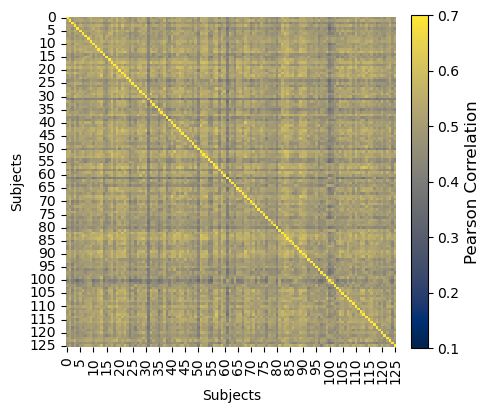

In [36]:
fig, ax = plt.subplots(figsize=(5,5))
hm = sns.heatmap(
    Id_FC_sbjs.values,
    vmin=0.1,
    vmax=0.7,
    cmap='cividis',
    square=True,
    ax=ax,
    cbar=False   # turn off automatic colorbar
)

# Add colorbar manually
cbar = ax.figure.colorbar(hm.get_children()[0], ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Pearson Correlation', fontsize=12)

# Labels and ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
ax.set_xlabel('Subjects')
ax.set_ylabel('Subjects')

plt.tight_layout()
plt.show()

In [39]:
fig.savefig(osp.join('figures', 'Figure02_D-FMRI_IdentifiabilityMatrix.png'), bbox_inches='tight')

In [40]:
Iself_values_FC = Id_FC_scans[within_sbj_mask].values.flatten()
Iself_values_FC = Iself_values_FC[~np.isnan(Iself_values_FC)]
Iself_FC        = Iself_values_FC.mean()
print('++ Introspection Iself = %.5f ' % Iself_FC)

++ Introspection Iself = 0.76239 


In [41]:
Iother_values_FC = Id_FC_scans[across_sbj_mask].values.flatten()
Iother_values_FC = Iother_values_FC[~np.isnan(Iother_values_FC)]
Iother_FC        = Iother_values_FC.mean() 
print('++ Introspection Iother = %.5f ' % Iother_FC)

++ Introspection Iother = 0.50102 


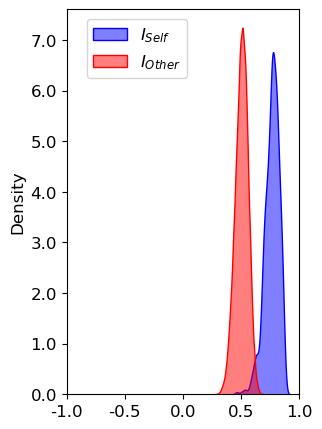

In [46]:
fig, ax = plt.subplots(figsize=(3,5))

sns.kdeplot(Iself_values_FC, label=r'$I_{Self}$', alpha=0.5, color='blue', fill=True, ax=ax)
sns.kdeplot(Iother_values_FC, label=r'$I_{Other}$', alpha=0.5, color='red', fill=True, ax=ax)

# Move legend inside the plot, bottom-left
ax.legend(
    loc='lower left',
    bbox_to_anchor=(0.05, 0.80),
    frameon=True,
    framealpha=0.8,
    fontsize=12,
)

# Set tick label size
ax.tick_params(axis='both', labelsize=12)

# Set axis labels (if you have them)
ax.set_ylabel('Density', fontsize=12)

# Set axis limits
ax.set_xlim(-1., 1.)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#plt.tight_layout()
plt.show()

In [47]:
fig.savefig(osp.join('figures', 'Figure02_E-FMRI_IselfAndIother.png'), bbox_inches='tight')

***

# 3. Identifiability Rate

## 3.1 Indentifibility Rate based on introspection data

1. Compute the experimental Identification Rate

In [48]:
def get_id_rate(id_matrix_sbj):
    n_scans          = id_matrix_sbj.shape[0]
    correct_id_count = 0    
    for r,row in id_matrix_sbj.iterrows():
        target_subject       = r[0]
        most_similar_subject = row.sort_values(ascending=False).index[0][0]
        if target_subject == most_similar_subject:
            correct_id_count += 1
    id_rate = 100 * correct_id_count / n_scans
    return id_rate

In [50]:
identification_rate_SNYCQ = get_id_rate(Id_SNYCQ_scans)
print('++ Introspection-based Identification Rate = %.2f %%' % (identification_rate_SNYCQ))

++ Introspection-based Identification Rate = 19.91 %


2. Do Permutation analysis

In [51]:
N_NULL_PERMS = 10000
SNYCQ_id_rate_null = pd.DataFrame(0,columns=['ID_Rate'],index=range(N_NULL_PERMS), dtype=float)
SNYCQ_id_rate_null.index.name = 'Permutation'

for i in tqdm(range(N_NULL_PERMS)):
    Id_matrix_shuffled = Id_SNYCQ_scans.copy()
    cols = Id_matrix_shuffled.columns.to_list()
    shuffle(cols)
    Id_matrix_shuffled.columns = pd.MultiIndex.from_tuples(cols, names=['Subject','Run'])
    this_perm_id_rate = get_id_rate(Id_matrix_shuffled)
    SNYCQ_id_rate_null.loc[i,'ID_Rate'] = this_perm_id_rate

100%|██████████| 10000/10000 [09:51<00:00, 16.90it/s]


/tmp/ipykernel_111073/2865345290.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14);
/tmp/ipykernel_111073/2865345290.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14);


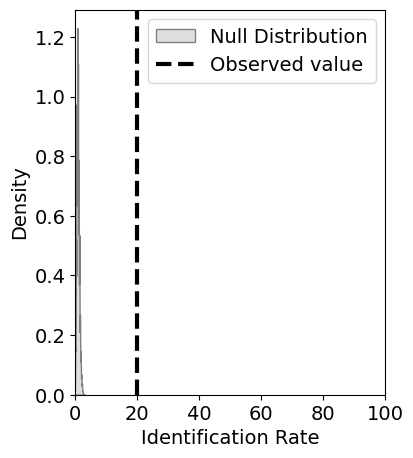

In [52]:
fig,ax = plt.subplots(1,1,figsize=(4,5))
plot = sns.kdeplot(data=SNYCQ_id_rate_null,x='ID_Rate',fill=True,label='Null Distribution',ax=ax, color='gray')
plot.set_xlabel("Identification Rate", fontsize=14)
plot.set_ylabel("Density", fontsize=14)
# Add the observed value line with label
plot.axvline(identification_rate_SNYCQ, color='black', linestyle='--', label='Observed value', linewidth=3)
# Force legend to show both entries
plot.set_xlim(0,100)
plot.legend(loc='upper right', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14);
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14);

In [53]:
fig.savefig(osp.join('figures', 'Figure02_F-FMRI_IdentificationRate.png'), bbox_inches='tight')

## 3.2. Identification Rate based on FC data

1. Get expiremantal identification rate

In [54]:
Id_Rate_FC = get_id_rate(Id_FC_scans)
print('++ FC-based Identification Rate = %.2f %%' % (Id_Rate_FC))

++ FC-based Identification Rate = 99.78 %


2. Bootstraping analysis

In [55]:
N_NULL_PERMS = 10000
FC_id_rate_null = pd.DataFrame(0,columns=['ID_Rate'],index=range(N_NULL_PERMS), dtype=float)
FC_id_rate_null.index.name = 'Permutation'

for i in tqdm(range(N_NULL_PERMS)):
    Id_matrix_shuffled = Id_FC_scans.copy()
    cols = Id_matrix_shuffled.columns.to_list()
    shuffle(cols)
    Id_matrix_shuffled.columns = pd.MultiIndex.from_tuples(cols, names=['Subject','Run'])
    this_perm_id_rate = get_id_rate(Id_matrix_shuffled)
    FC_id_rate_null.loc[i,'ID_Rate'] = this_perm_id_rate

100%|██████████| 10000/10000 [09:49<00:00, 16.95it/s]


/tmp/ipykernel_111073/853250501.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14);
/tmp/ipykernel_111073/853250501.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14);


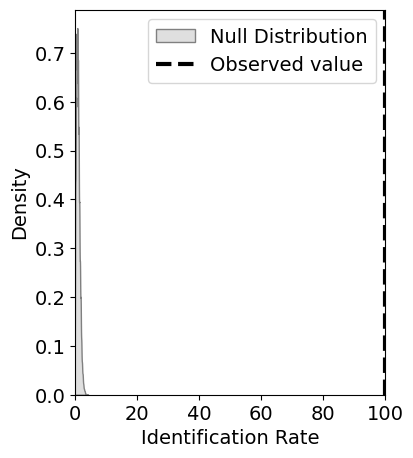

In [56]:
fig,ax = plt.subplots(1,1,figsize=(4,5))
plot = sns.kdeplot(data=FC_id_rate_null,x='ID_Rate',fill=True,label='Null Distribution',ax=ax, color='gray')
plot.set_xlabel("Identification Rate", fontsize=14)
plot.set_ylabel("Density", fontsize=14)
# Add the observed value line with label
plot.axvline(Id_Rate_FC, color='black', linestyle='--', label='Observed value', linewidth=3)
# Force legend to show both entries
plot.set_xlim(0,100)
plot.legend(loc='upper right', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14);
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14);

In [57]:
fig.savefig(osp.join('figures', 'Figure02_G-FMRI_IdentificationRate.png'), bbox_inches='tight')  